In [11]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch05/titanic.csv'
titanic_data = pd.read_csv(url)
print(titanic_data.head( ))
print(titanic_data.info( ))



   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age  sibsp  parch            ticket     fare cabin embarked  
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S  
1  female  38.0      1      0          PC 17599  71.2833   C85        C  
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
3  female  35.0      1      0            113803  53.1000  C123        S  
4    male  35.0      0      0            373450   8.0500   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   C

In [12]:
# count missing values in each column
print(titanic_data.isnull( ).sum( ))


survived      0
pclass        0
name          0
sex           0
age         177
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
dtype: int64


In [13]:
# check for duplicate rows
print(titanic_data.duplicated( ).sum( ))


0


In [14]:
# segregate numerical and categorical columns
numerical_cols = titanic_data.select_dtypes(include = ['int64', 'float64']).columns.tolist( )
categorical_cols = titanic_data.select_dtypes(include = ['object']).columns.tolist( )
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)



Numerical Columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical Columns: ['name', 'sex', 'ticket', 'cabin', 'embarked']


In [15]:
# statistical summary of age
print(titanic_data['age'].describe( ))


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


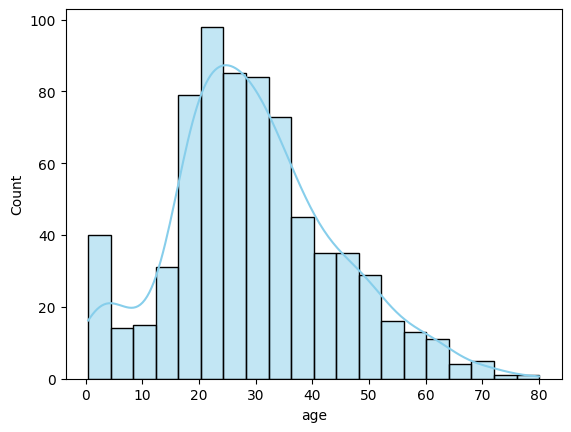

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(titanic_data['age'], kde = True, bins = 20, color = 'skyblue')
plt.show( )


In [17]:
print(titanic_data['age'].skew( ))

0.38910778230082704


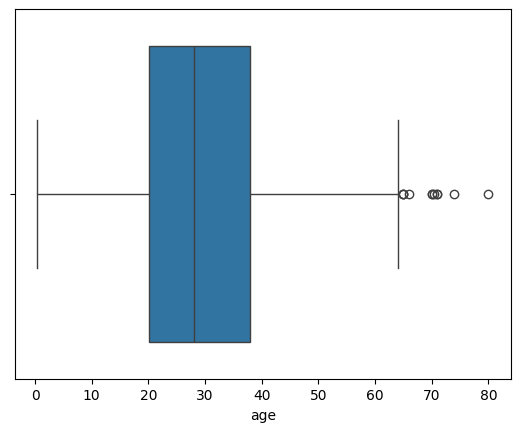

In [18]:
sns.boxplot(x = titanic_data['age'])
plt.show( )


In [19]:
print(titanic_data['fare'].describe( ))

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


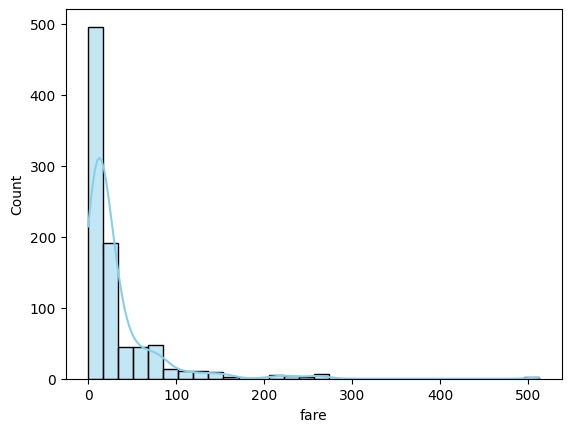

In [20]:
sns.histplot(titanic_data['fare'], kde= True, bins = 30, color = 'skyblue')
plt.show( )


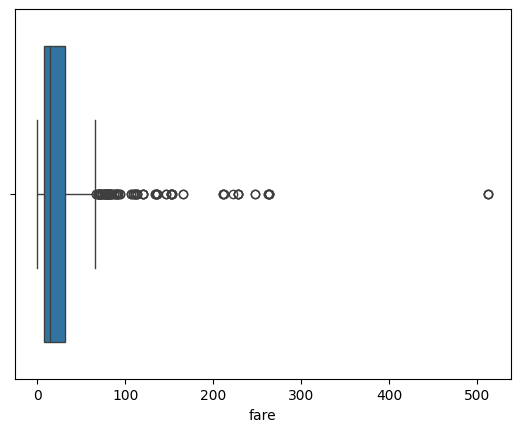

In [21]:
sns.boxplot(x = titanic_data['fare'])
plt.show( )


In [22]:
td = titanic_data[titanic_data['fare'] > 250]
print(td[['name', 'ticket', 'fare']])


                                      name    ticket      fare
27          Fortune, Mr. Charles Alexander     19950  263.0000
88              Fortune, Miss. Mabel Helen     19950  263.0000
258                       Ward, Miss. Anna  PC 17755  512.3292
311             Ryerson, Miss. Emily Borie  PC 17608  262.3750
341         Fortune, Miss. Alice Elizabeth     19950  263.0000
438                      Fortune, Mr. Mark     19950  263.0000
679     Cardeza, Mr. Thomas Drake Martinez  PC 17755  512.3292
737                 Lesurer, Mr. Gustave J  PC 17755  512.3292
742  Ryerson, Miss. Susan Parker "Suzette"  PC 17608  262.3750


In [25]:
# calculate group size based on Ticket
titanic_data['GroupSize'] = titanic_data.groupby('ticket')['ticket'].transform('count')

# calculate individual fare
titanic_data['IndividualFare'] = titanic_data['fare'] / titanic_data['GroupSize']
# preview the new column
print(titanic_data[['ticket', 'fare', 'GroupSize', 'IndividualFare']].head( ))


             ticket     fare  GroupSize  IndividualFare
0         A/5 21171   7.2500          1          7.2500
1          PC 17599  71.2833          1         71.2833
2  STON/O2. 3101282   7.9250          1          7.9250
3            113803  53.1000          2         26.5500
4            373450   8.0500          1          8.0500


In [26]:
print(titanic_data[['fare','IndividualFare']].describe( ))

             fare  IndividualFare
count  891.000000      891.000000
mean    32.204208       17.788989
std     49.693429       21.218157
min      0.000000        0.000000
25%      7.910400        7.762500
50%     14.454200        8.850000
75%     31.000000       24.288200
max    512.329200      221.779200


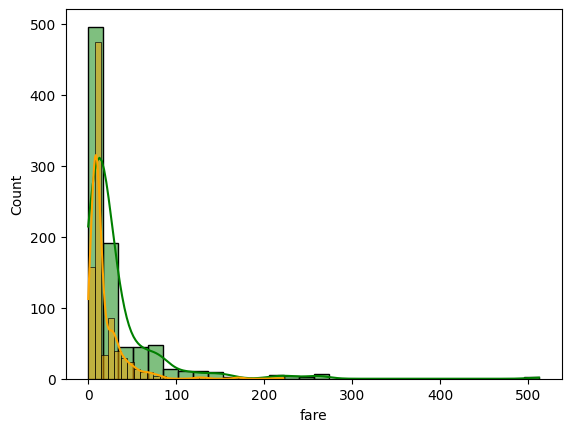

In [27]:
# histogram comparison
sns.histplot(titanic_data['fare'], kde = True, bins = 30, color = 'green', label = 'Original Fare')
sns.histplot(titanic_data['IndividualFare'], kde = True, bins = 30, color = 'orange', label = 'Individual Fare')
plt.show( )


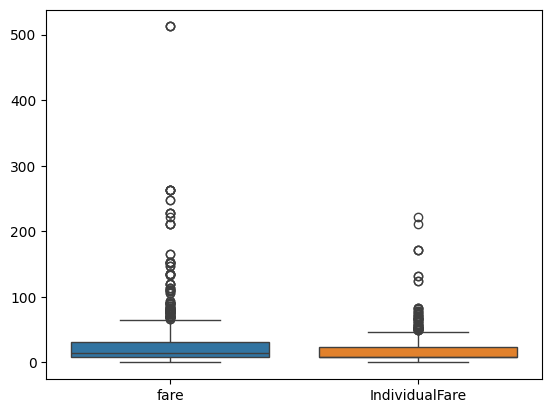

In [28]:
sns.boxplot(titanic_data[['fare', 'IndividualFare']])
plt.show( )


/tmp/ipykernel_520/3167929487.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'survived', data = titanic_data, palette = 'viridis')


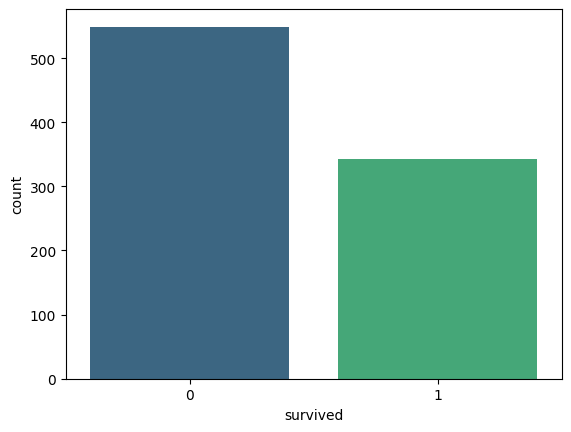

/tmp/ipykernel_520/3167929487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'pclass', data = titanic_data, palette = 'viridis')


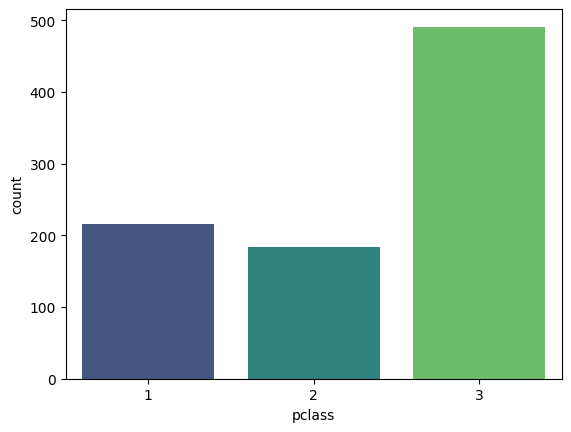

/tmp/ipykernel_520/3167929487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'sex', data = titanic_data, palette = 'viridis')


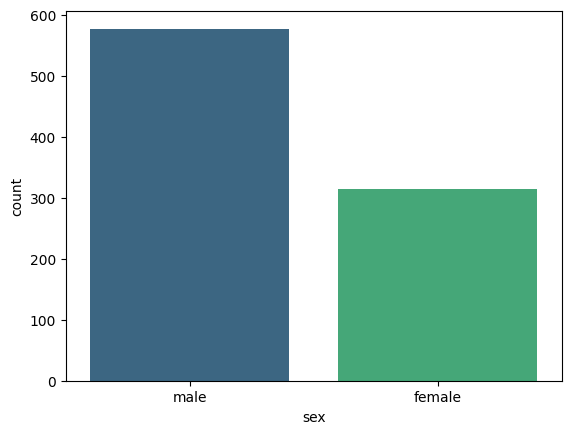

/tmp/ipykernel_520/3167929487.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'embarked', data = titanic_data, palette = 'viridis')


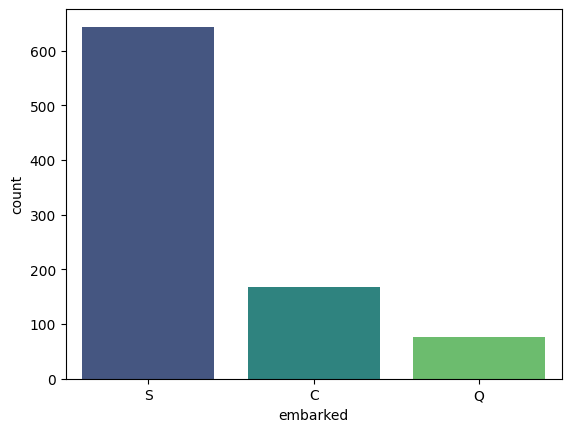

In [31]:
sns.countplot(x = 'survived', data = titanic_data, palette = 'viridis')
plt.show( )
sns.countplot(x = 'pclass', data = titanic_data, palette = 'viridis')
plt.show( )
sns.countplot(x = 'sex', data = titanic_data, palette = 'viridis')
plt.show( )
sns.countplot(x = 'embarked', data = titanic_data, palette = 'viridis')
plt.show( )


In [32]:
# create FamilySize column
titanic_data['FamilySize'] = titanic_data['sibsp'] + titanic_data['parch'] + 1


In [34]:
# statistical summary of FamilySize
print(titanic_data['FamilySize'].describe( ))


count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


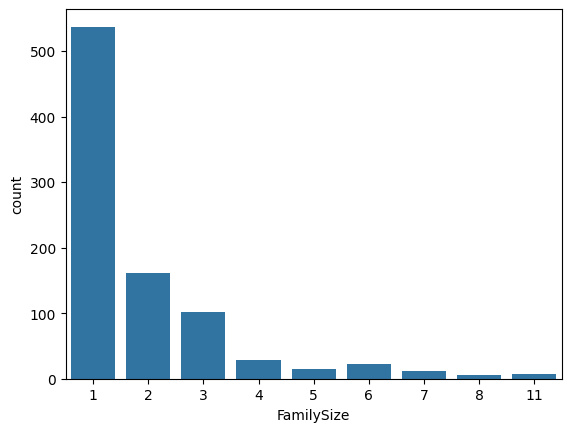

In [35]:
sns.countplot(x = 'FamilySize', data = titanic_data)
plt.show( )


In [37]:
# extract the deck from the Cabin column
titanic_data['Deck'] = titanic_data['cabin'].str[0].fillna('M')


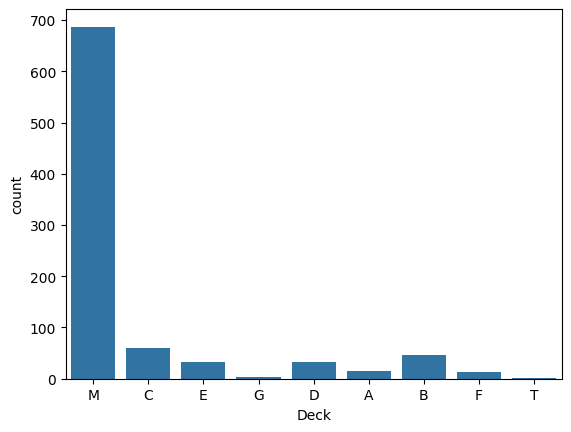

In [38]:
sns.countplot(x = 'Deck', data = titanic_data)
plt.show( )


In [39]:
# extract title using string manipulation
titanic_data['Title'] = titanic_data['name'].str.extract('([A-Za-z]+)\.', expand = False)
# print value counts for Title
print(titanic_data['Title'].value_counts( ))


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_520/2306689243.py:2: SyntaxWarning: invalid escape sequence '\.'
  titanic_data['Title'] = titanic_data['name'].str.extract('([A-Za-z]+)\.', expand = False)


In [41]:
# define rare titles to group
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Don', 'Jonkheer', 'Sir', 'Lady', 'Countess']
# replace rare titles with 'Others'
titanic_data['Title'] = titanic_data['Title'].replace(rare_titles, 'Others')
titanic_data['Title'] = titanic_data['Title'].replace('Ms', 'Miss')

# Mme is a French courtesy title for a married woman
# Mlle is a French courtesy title for an unmarried woman
titanic_data['Title'] = titanic_data['Title'].replace('Mme', 'Mrs')
titanic_data['Title'] = titanic_data['Title'].replace('Mlle', 'Miss')


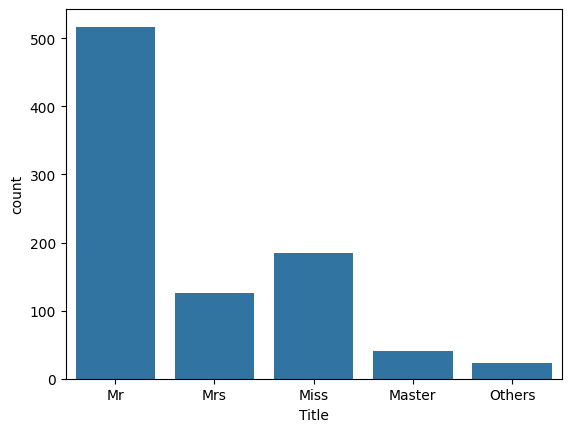

In [42]:
sns.countplot(x = 'Title', data = titanic_data)
plt.show( )


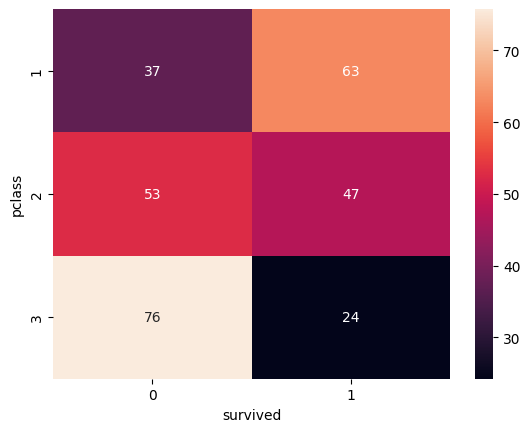

In [43]:
pclass_survived_ct = pd.crosstab(titanic_data['pclass'], titanic_data['survived'],normalize = 'index') * 100
sns.heatmap(pclass_survived_ct, annot = True)
plt.show( )


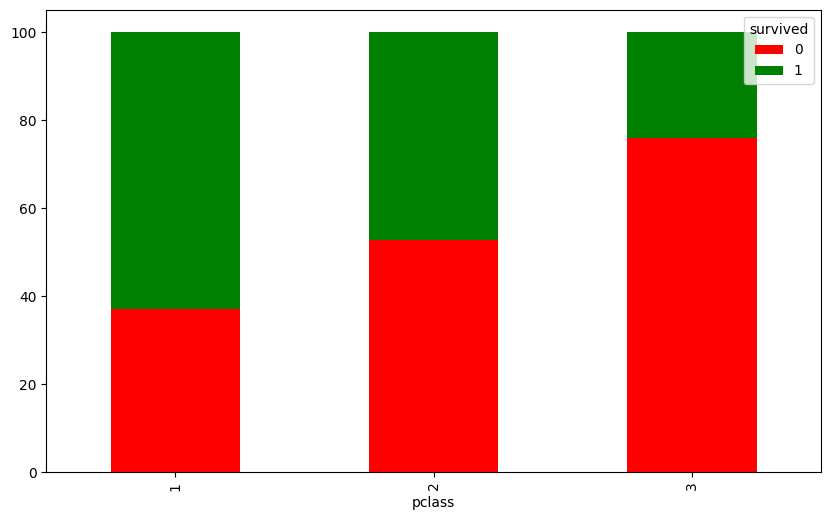

In [44]:
pclass_survived_ct.plot(kind = 'bar', stacked = True, figsize = (10, 6), color = ['red', 'green'])
plt.show( )


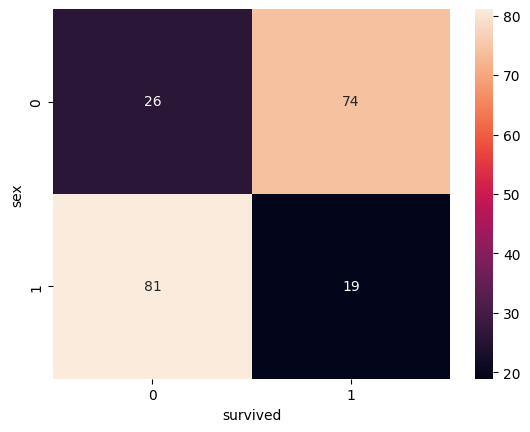

In [69]:
sex_survived_ct = pd.crosstab(titanic_data['sex'], titanic_data['survived'],normalize = 'index')*100
sns.heatmap(sex_survived_ct, annot = True)
plt.show( )


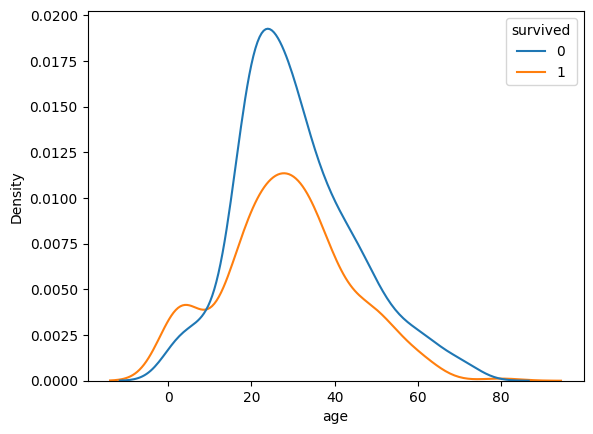

In [46]:
sns.kdeplot(data = titanic_data, x = 'age', hue = 'survived')
plt.show( )


In [47]:
print(titanic_data.groupby('survived')['age'].describe( ))

          count       mean        std   min   25%   50%   75%   max
survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


<Axes: xlabel='IndividualFare', ylabel='Density'>

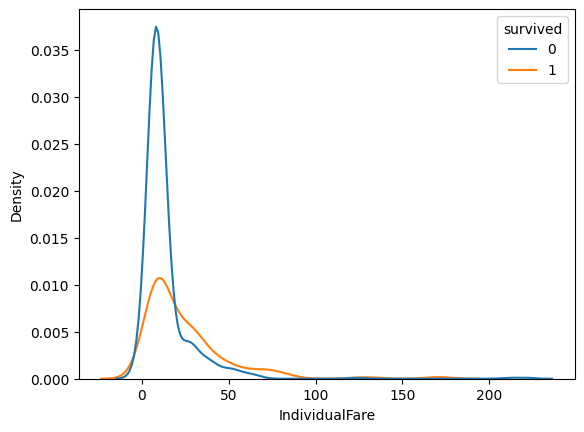

In [48]:
sns.kdeplot(data = titanic_data, x = 'IndividualFare', hue = 'survived')
plt.show( )

In [49]:
print(titanic_data.groupby('survived')['IndividualFare'].describe( ))

          count       mean        std  min    25%    50%   75%       max
survived                                                                
0         549.0  13.523869  17.137983  0.0  7.725   8.05  13.0  221.7792
1         342.0  24.635628  25.034579  0.0  7.950  13.00  30.0  170.7764


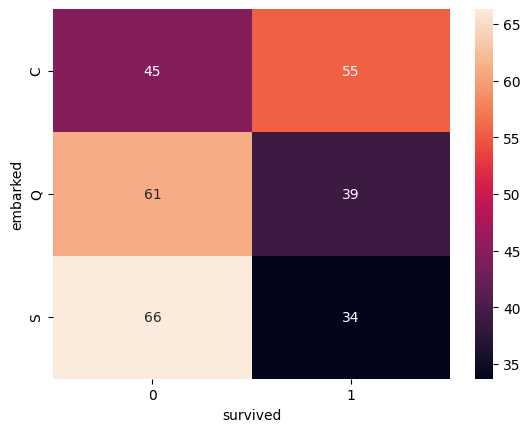

In [80]:
embarked_survived_ct = pd.crosstab(titanic_data['embarked'],
                                      titanic_data['survived'],normalize = 'index')*100
sns.heatmap(embarked_survived_ct, annot = True)
plt.show( )

/tmp/ipykernel_520/145045732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = family_survival.index, y = family_survival.values, palette = 'Blues')


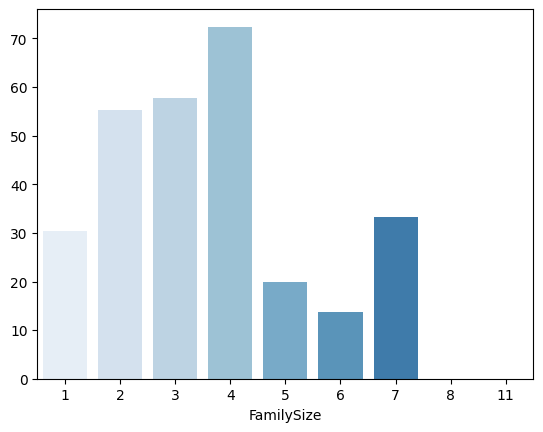

In [79]:
family_survival = titanic_data.groupby('FamilySize')['survived'].mean( ) * 100
sns.barplot(x = family_survival.index, y = family_survival.values, palette = 'Blues')
plt.show( )

/tmp/ipykernel_520/4012341104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = title_survival.index, y = title_survival.values, palette = 'Blues')


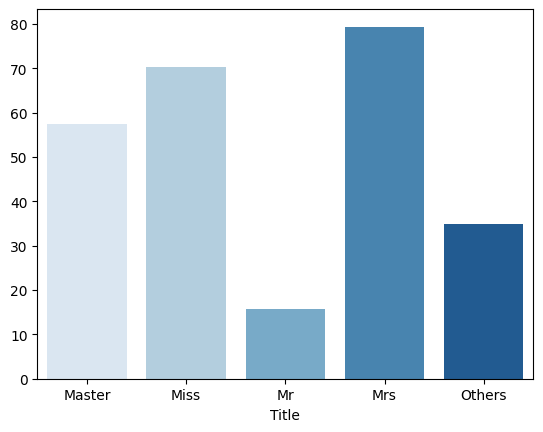

In [78]:
title_survival = titanic_data.groupby('Title')['survived'].mean( ) * 100
sns.barplot(x = title_survival.index, y = title_survival.values, palette = 'Blues')
plt.show( )

/tmp/ipykernel_520/2606788097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = deck_survival.index, y = deck_survival.values, palette = 'Blues')


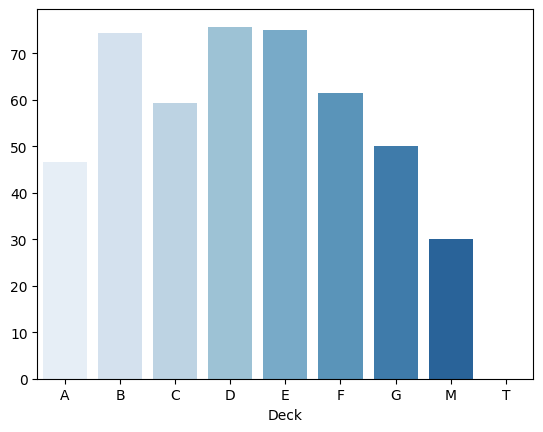

In [77]:
deck_survival = titanic_data.groupby('Deck')['survived'].mean( ) * 100
sns.barplot(x = deck_survival.index, y = deck_survival.values, palette = 'Blues')
plt.show( )



<Axes: xlabel='pclass', ylabel='survived'>

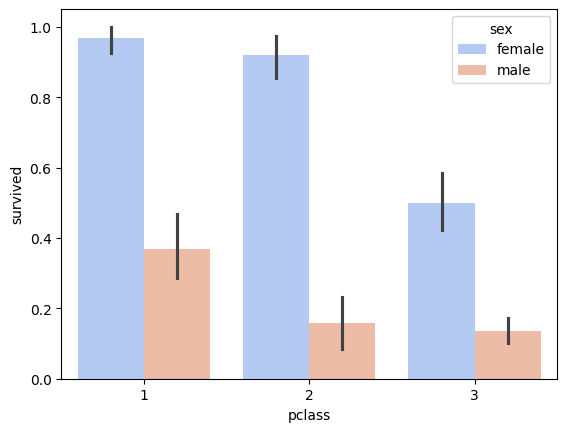

In [54]:
sns.barplot(data = titanic_data, x = 'pclass', y = 'survived', hue = 'sex', palette = 'coolwarm')
plt.show( )


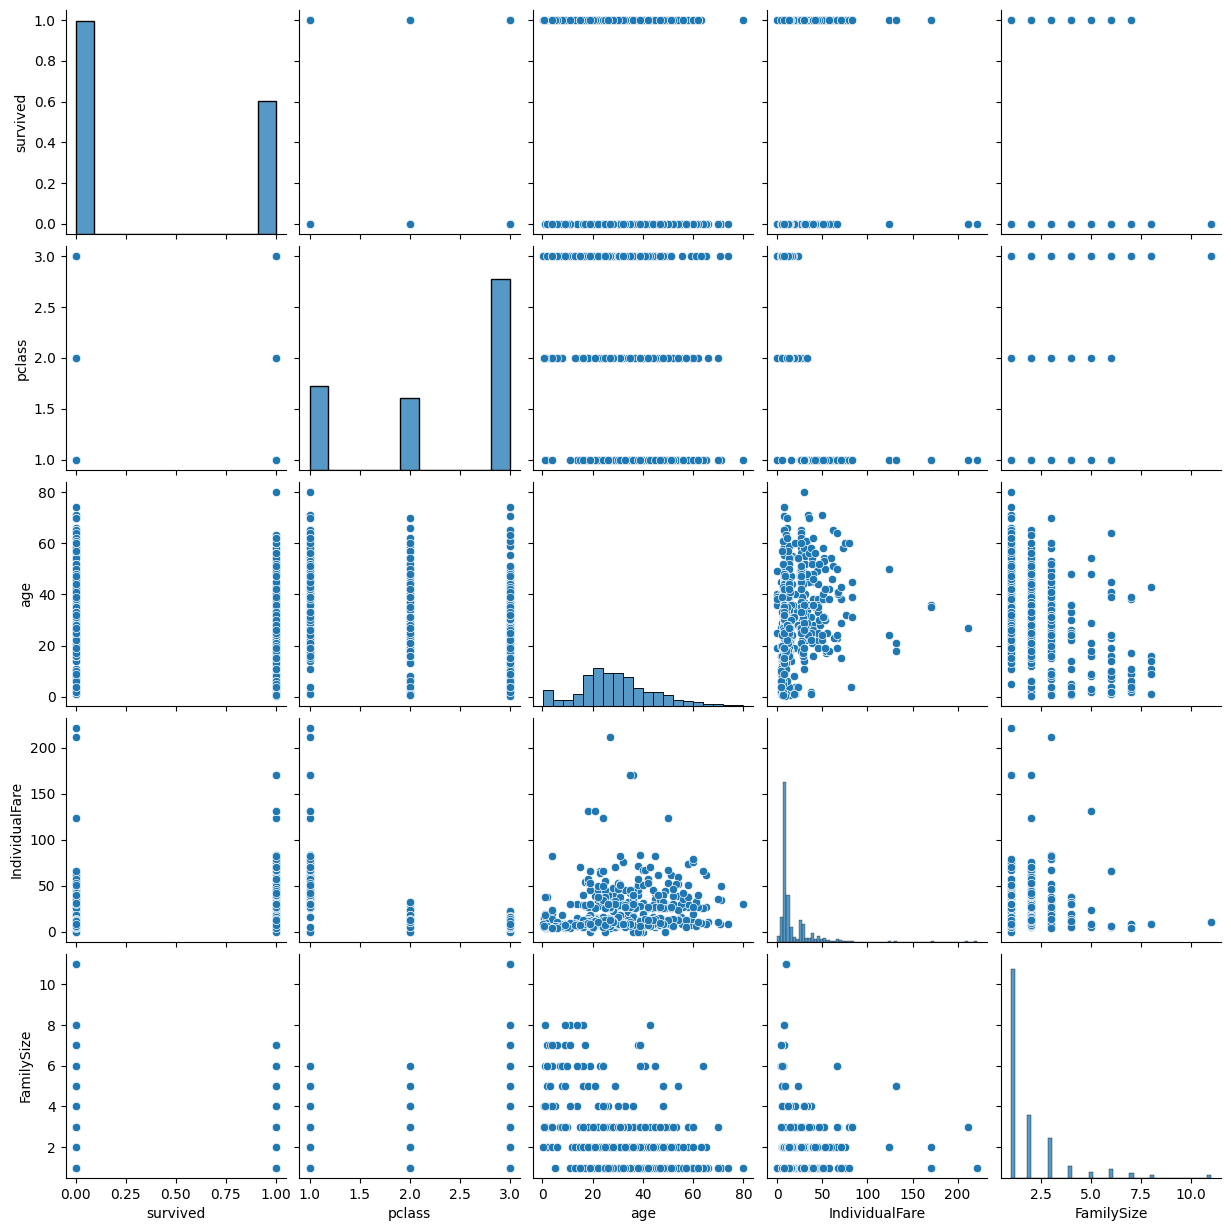

In [55]:
sns.pairplot(titanic_data.drop(columns = ['sibsp', 'parch', 'fare',	'GroupSize']))
plt.show( )

In [64]:
from sklearn.preprocessing import LabelEncoder

# separate features based on encoding type
label_encode_cols = ['sex']
one_hot_encode_cols = ['embarked', 'Title', 'Deck']
# apply Label Encoding
label_encoders = { }
for col in label_encode_cols :
    le = LabelEncoder( )
    titanic_data[col] = le.fit_transform(titanic_data[col].astype(str))
    label_encoders[col] = le

# apply One-Hot Encoding
encoded_data = pd.get_dummies(titanic_data, columns = one_hot_encode_cols)


In [65]:
# Combine numerical and encoded categorical columns
encoded_data = encoded_data.select_dtypes(include=['float64', 'int64','bool'])

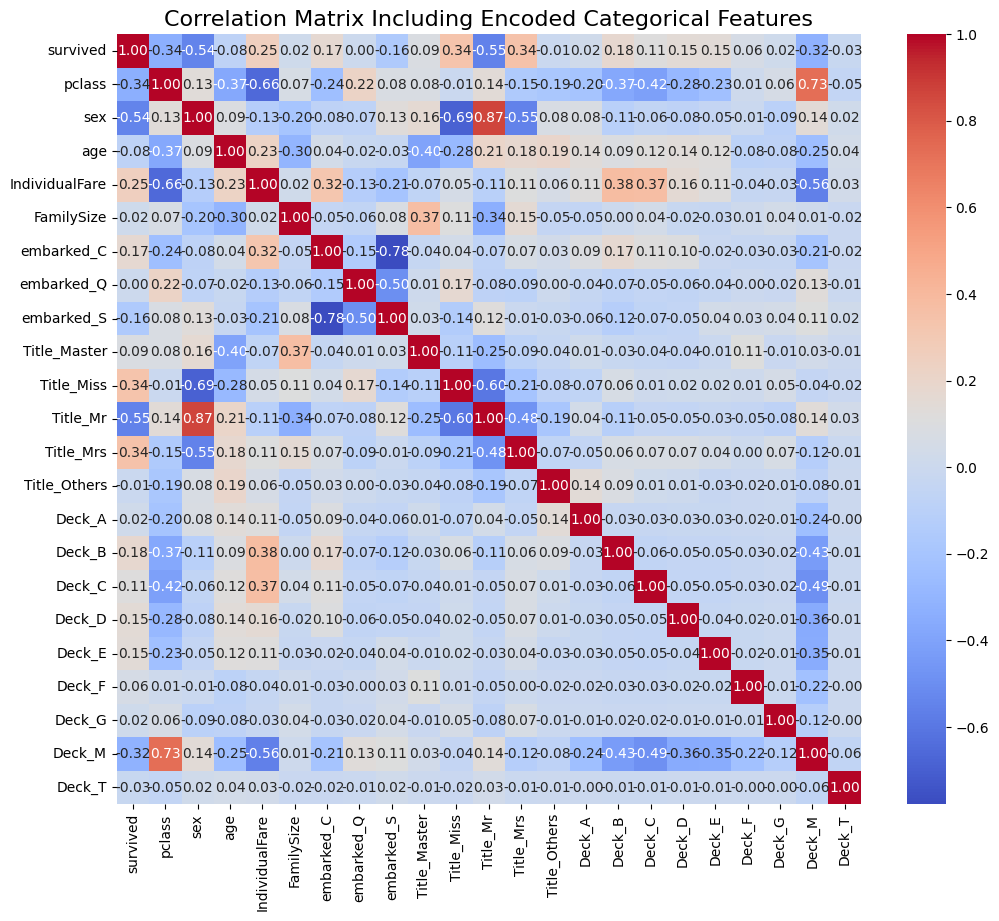

In [66]:
correlation_matrix = encoded_data.drop(columns = ['sibsp', 'parch', 'GroupSize', 'fare']).corr( )
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Including Encoded Categorical Features', fontsize=16)
plt.show()